# Guide to the UVMOS ETC

Jade Yeung, May 2026

## 1. Importing Packages

This section shows how to import the packages you need to be able to use the ETC.  For certain plots you may need to use $\verb+matplotlib.pyplot+$.  Then you need to import $\verb+castor_etc+$ from the CASTOR container on CANFAR and from that import $\verb+telescope+$, $\verb+background+$, $\verb+sources+$, and $\verb+spectrum+$.  The multi-slit version of the UVMOS ETC is currently not available on CANFAR, so to use it you need to download it from the CASTOR-ETC Github and then upload it in CANFAR.  Then you need to import all the functions.

In [30]:
import matplotlib.pyplot as plt

In [3]:
import castor_etc # Import the castor etc from CASTOR container on CANFAR
from castor_etc import telescope, background, sources, spectrum
from uvmos_spectroscopy import * # This might u the previous version of the UVMOS ETC that doesn't support multi-slit spectroscopy.
# If you are getting a type error saying that you can't input a list while setting up the ETC, rename the uvmos_spectroscopy file
# you downloaded and change the name of it here to match.

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


## 2. Setting Up the ETC

In this section, you will set up the UVMOS ETC.  

First you need to define a telescope and background object.  The default telescope object is set to CASTOR's parameters, but you can change the parameters to represent any telescope.

In [4]:
### Define a telescope object and a background object

my_telescope=telescope.Telescope()
my_background=background.Background()

Now you need to define a list of source objects.  $\verb+num_sources+$ is the number of sources you wish to use.  You can also define custom spectra and blackbodies instead of using the $\verb+pickles+$ library.

In [5]:
### Define source objects

my_sources = [] # Define a list to put the individual source objects into

# I'm going to define 3 sources with different spectral types and magnitudes
num_sources = 3 # The number of sources you want to make
magnitudes = [1, 5, 10] # The AB magnitudes of each source
spectral_types = ["g0v", "f0v", "b0v"] # See the pickles library website for a full list of available stellar spectra.

for i in range(num_sources):
    my_source=sources.PointSource()
    my_source.use_pickles_spectrum(spectral_types[i])
    my_source.norm_to_AB_mag(magnitudes[i])
    my_sources.append(my_source)

If there are multiple sources, you need to specify coordinates for each source.  Make sure that the length of the RA and DEC offsets match the number of sources you defined above.  The field RA and DEC are the center coordinate of the field in degrees.  

After specifying the coordinates, you can initialize the UVMOS ETC using the $\verb+UVMOS_Spectroscopy()+$ function.  $\verb+case+$ determines which orientation of the DMD and the dispersion.  Case 1 has the DMD at a $45^\circ$ angle relative to the detector.  Case 2 has the DMD aligned with the detector, but with the dispersion at a $45^\circ$ angle.

In [6]:
### Define coordinates and slit orientations

delta_ra = [0.5 , 0.2, 1] # List of RA offsets for each source
delta_dec = [0.1, 0.2, -0.3] # List of DEC offsets
theta_list = [0, 60, 130] # The orientation of the source

field_centre_ra = 186.1 # The RA of the centre of the field in degrees
field_centre_dec = 12.3 # The DEC of the centre of the field in degrees

# Initialize the UVMOS ETC
uvmos_etc=UVMOS_Spectroscopy(my_telescope, my_sources, my_background, field_centre_ra, field_centre_dec, delta_ra = delta_ra, delta_dec = delta_dec, theta = theta_list, case = 1)
# Case determines which orientation of the DMD to use.  See Yeung+ 2026 for more details.

## 3. Using the ETC

The $\verb+show_slits()+$ function displays the location of each slit on the detector.  The slit size is very small compared to the size of the detector, so they might be difficult to see.  The slits are in red.  This function does not display an image, it only saves the figure as "$\verb+detector_fov_image.png+$".

In [7]:
### Displaying the slits on the detector

uvmos_etc.show_slits()

# This saves the image as "detector_fov_image.png"

The $\verb+show_individual_slits()+$ function shows how the point source and the slit would look on the sky and NOT how it would look on the detector.  Since point sources are isotropic, and pixels are not considered, it looks the same regardless of the slit orientation.  This is why despite the user specifying a slit orientation, the slits do not appear to be rotated.

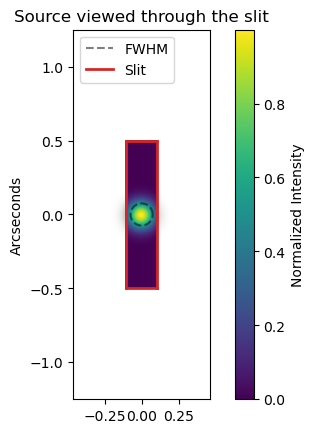

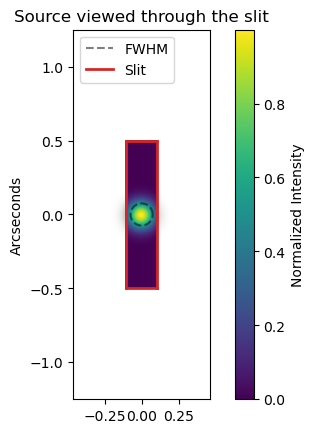

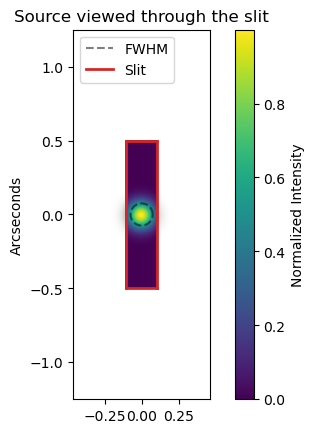

In [9]:
### Displaying what each slit looks like (not in pixels)

uvmos_etc.show_individual_slits()

The function $\verb+calc_slit_transmission()+$ displays the slit transmission.  This is how much of the point source's light passes through the slit.  This function does not show the spectrographic throughput.  This function is not required to be called to get the SNR or the exposure time (or any of the other plots), but if you want to see the transmission, you need to set $\verb+print_transmission_fact=True+$.

In [29]:
### Displaying the slit transmission

fractional_slit_transmission = uvmos_etc._calc_slit_transmission(print_transmission_fact=True)

Fractional slit transmission (2D estimation) 0.8077796417038152
Fractional slit loss (2D estimation) 0.19222035829618478
Fractional slit transmission (2D estimation) 0.8104266449202955
Fractional slit loss (2D estimation) 0.18957335507970452
Fractional slit transmission (2D estimation) 0.8118750657849898
Fractional slit loss (2D estimation) 0.1881249342150102


The function $\verb+show_source_pix_weights()+$ shows the pixel weights for each source.

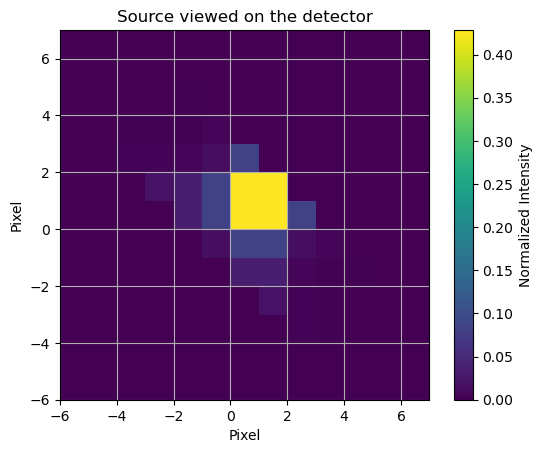

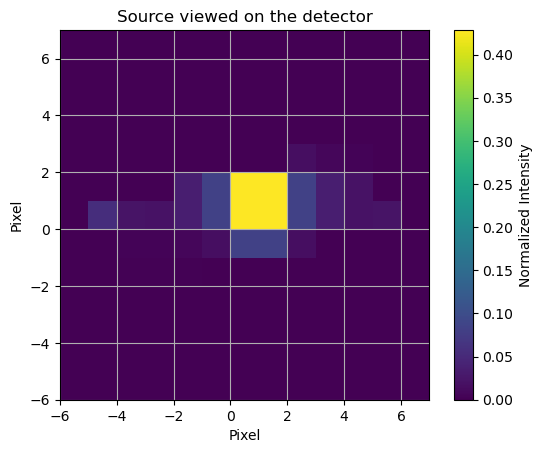

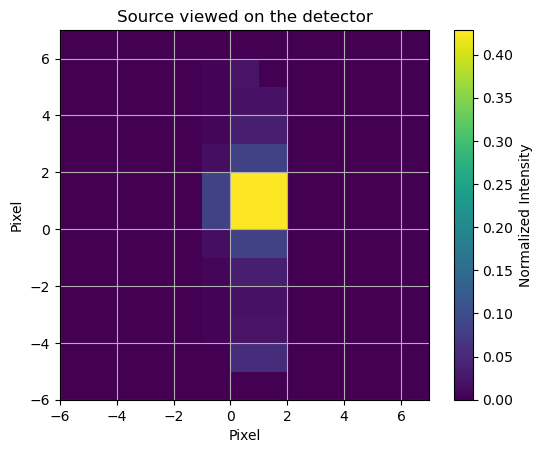

In [11]:
### Displaying the pixel weights

uvmos_etc.show_source_pix_weights()

The function $\verb+show_slit_image()+$ is a function that returns the slit image with the source light smeared out over a range of wavelengths and the center pixels of each source.  If you want to display the slit image, you need to plot it.  The parameter $\verb+wavelength+$ is the desired wavelength in nanometers.  Note that this is in different units from the wavelength you need to specify to get the SNR and the exposure time, which is in angstroms.

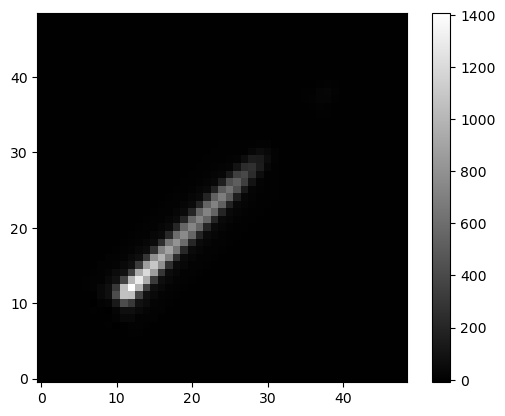

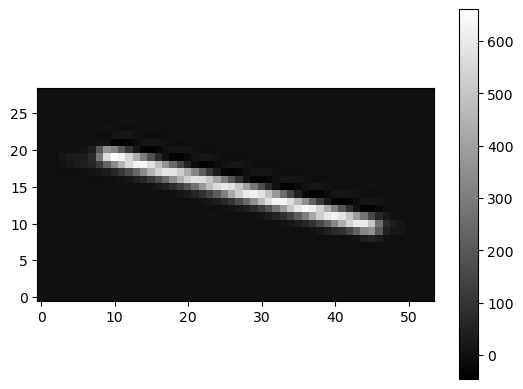

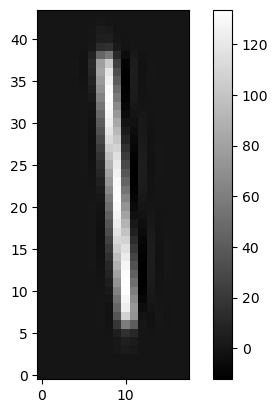

In [17]:
### Displaying the smeared out slits

# Need to specify a wavelength
wavelength = 200 # nm

slit_images, center_pixels = uvmos_etc.show_slit_image(wavelength) 
# slit_images are the images of the smeared out slit and center pixels are the center pixel of each source.

# Plot each image
for slit in slit_images:
    plt.imshow(slit, cmap = "gray", origin = "lower")
    plt.colorbar()
    plt.show()

The function $\verb+calc_source_CASTORSpectrum()+$ calculates the spectrum and returns the wavelengths, the spectra, the number of pixels used in the spectrum extraction, and the detector arrays. 

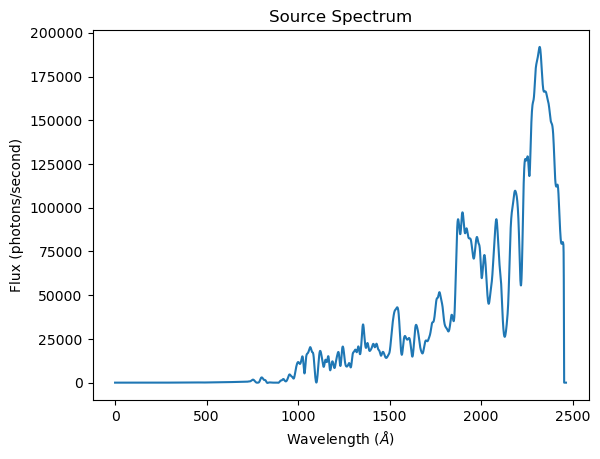

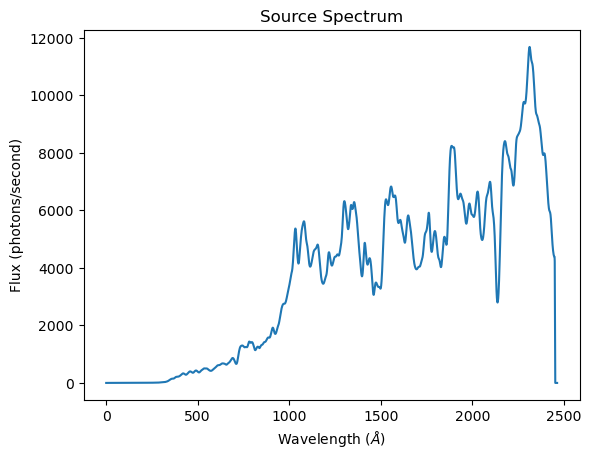

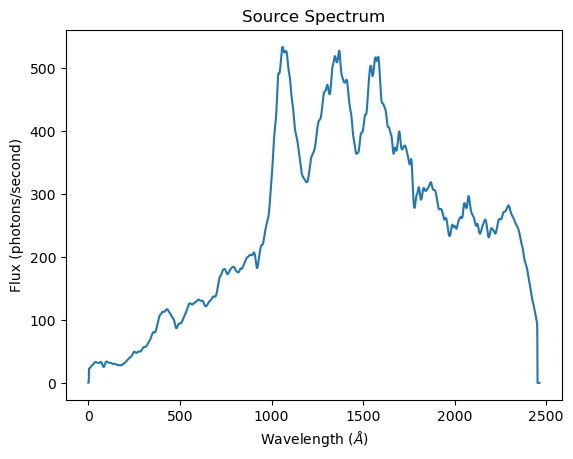

In [33]:
### Getting the source spectrum

uvmos_etc.calc_source_CASTORSpectrum()

# After you run this function, you can get:
# uvmos_etc.waves_CASTORSpectrum_list
# uvmos_etc.source_CASTORSpectrum_list
# uvmos_etc.source_extracted_numpixs_list
# uvmos_etc.source_detector_list

for i in uvmos_etc.source_CASTORSpectrum_list:
    plt.plot(i)
    plt.title("Source Spectrum")
    plt.xlabel(r"Wavelength ($\AA$)")
    plt.ylabel("Flux (photons/second)")
    plt.show()

The function $\verb+calc_background_CASTORSpectrum()+$ calculates the background spectrum and returns the wavelengths, the background spectra, and the number of pixels used in the spectrum extraction.  Here the background spectrum for each source is the same because I did not specify a spectra for each beackground object.  

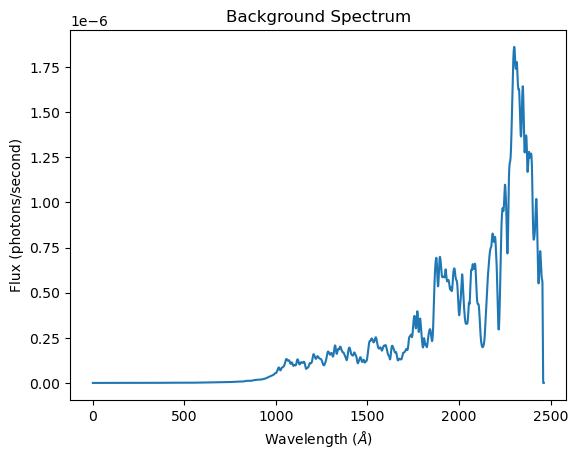

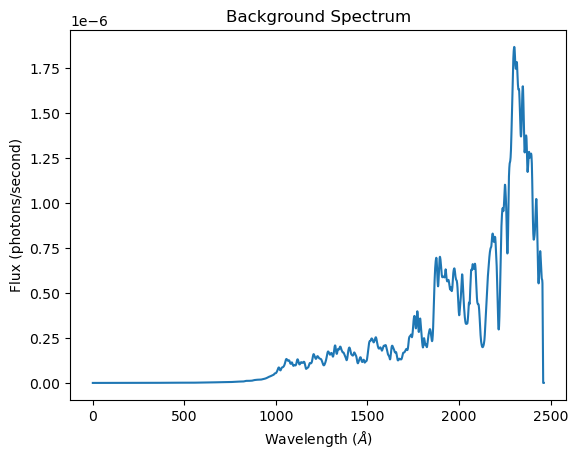

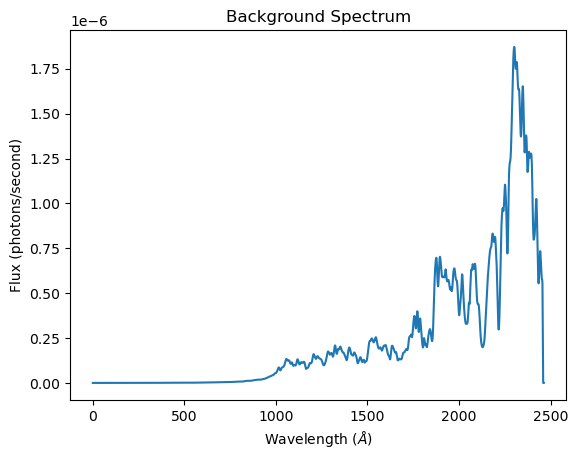

In [32]:
### Getting the background transmission

uvmos_etc.calc_background_CASTORSpectrum() # Calculate the background spectrum

# This function gets:
# uvmos_etc.waves_CASTORSpectrumBackground_list
# uvmos_etc.background_CASTORSpectrum_list
# uvmos_etc.background_extracted_numpixs_list

for i in uvmos_etc.background_CASTORSpectrum_list:
    plt.plot(i)
    plt.title("Background Spectrum")
    plt.xlabel(r"Wavelength ($\AA$)")
    plt.ylabel("Flux (photons/second)")
    plt.show()

The function $\verb+calc_t_from_snr()+$ is a function that returns the exposure time in seconds given a desired SNR and a wavelength.  Note that wavelength here is in angstroms not nanometers.  If you don't care about any of the previous plots, and only care about finding the exposure time, then this is the only function you have to run in Section 3.

In [22]:
### Finding the exposure time for a given SNR

desired_snr = 10
wavelength = 2000 # angstroms

t = uvmos_etc.calc_t_from_snr(desired_snr, wavelength)

for i in t:
    print("The exposure time needed for an SNR of", desired_snr, "is", round(i, 3), "s")

The exposure time needed for an SNR of 10 is 3.275 s
The exposure time needed for an SNR of 10 is 3.983 s
The exposure time needed for an SNR of 10 is 27.104 s


The function $\verb+calc_snr_from_t+$ returns a SNR for a given exposure time and wavelength.  Note that similarly to the previous function, wavelength is in angstrom, not nanometers.  Again, if you only want the exposure time, you can skip running all of the previous functions in Section 3 and only run this function.

In [23]:
### Finding the SNR for a given exposure time

exposure_time = 100 # seconds
wavelength = 2000 # angstroms

snr = uvmos_etc.calc_snr_from_t(exposure_time, wavelength)

for i in snr:
    print("The snr for an exposure time of", exposure_time, "seconds is", round(i, 3))

The snr for an exposure time of 100 seconds is 239.795
The snr for an exposure time of 100 seconds is 204.465
The snr for an exposure time of 100 seconds is 35.881


### 4. View UVMOS Properties

This section focuses on functions that display plots about the properties of the UVMOS.  It is optional to run any of these functions.

The first function in this section, $\verb+showTransmission()+$ displays the spectrographic throughput of CASTOR.

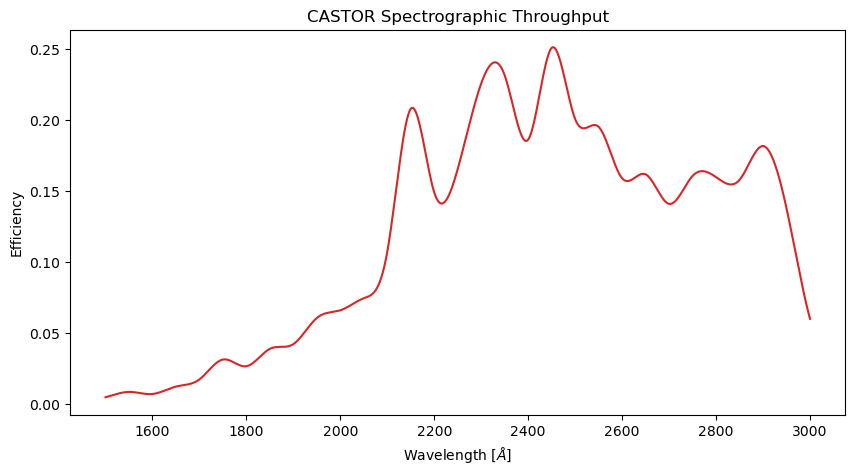

In [27]:
### Show transmission

uvmos_etc.showTransmission()

The function $\verb+showResolvingPower()+$ shows the resolving power of the UVMOS spectrograph as a function of wavelength.

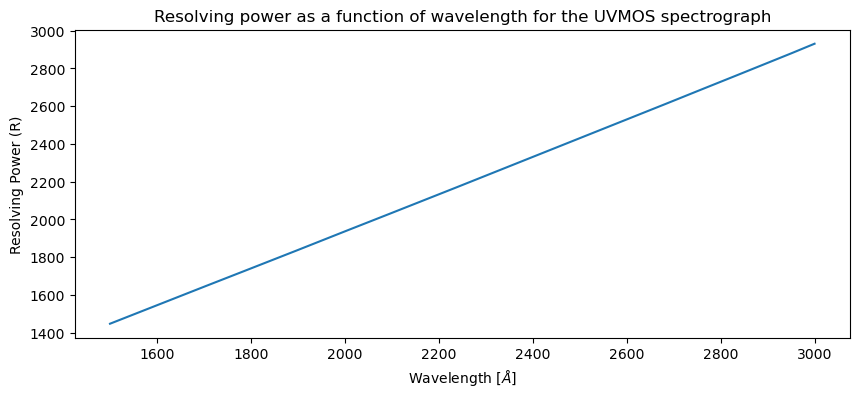

In [28]:
### Show resolving power

uvmos_etc.showResolvingPower()